# Input: Same patient history
# Comparison:
#   Case 1: Without drug (no intervention)
#   Case 2: With drug administered
# Output: Compare differences in BP, HR, and other vital signs to observe hemodynamic changes

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pandas numpy torch scikit-learn matplotlib

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
chartevents_path = "/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2/icu/chartevents.csv.gz"
ditems_path = "/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2/icu/d_items.csv.gz"
inputevents_path= "/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2/icu/inputevents.csv.gz"

df = pd.read_csv(chartevents_path, compression='gzip')#vitals data
d_items = pd.read_csv(ditems_path, compression='gzip')#dictionary / map table(to get labels)
drugs = pd.read_csv(inputevents_path, compression='gzip')#actual medicine data

In [4]:
df.head(10)


,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,225054,On,NaN,NaN,0.0
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:43:00,223769,100,100.0,%,0.0
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,223956,Atrial demand,NaN,NaN,0.0
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224866,Yes,NaN,NaN,0.0
4,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0
5,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224751,52,52.0,bpm,0.0
6,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:44:00,227969,"Quiet, calm space",NaN,NaN,0.0
7,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:46:00,223935,Doppler,NaN,NaN,0.0
8,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:48:00,223782,Intermittent,NaN,NaN,0.0
9,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224773,Cool,NaN,NaN,0.0


In [5]:
d_items.head(10)


,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,226228,Gender,Gender,chartevents,ADT,NaN,Text,NaN,NaN
1,226545,Race,Race,chartevents,ADT,NaN,Text,NaN,NaN
2,229877,Suction events (CH),Suction events (CH),chartevents,ECMO,NaN,Text,NaN,NaN
3,229875,Oxygenator visible (CH),Oxygenator visible (CH),chartevents,ECMO,NaN,Text,NaN,NaN
4,229266,Cannula sites visually inspected (ECMO),Cannula sites visually inspected (ECMO),chartevents,ECMO,NaN,Text,NaN,NaN
5,229846,Sweep (CH),Sweep (CH),chartevents,ECMO,NaN,Text,NaN,NaN
6,229267,Emergency Equipment at bedside (ECMO),Emergency Equipment at bedside (ECMO),chartevents,ECMO,NaN,Text,NaN,NaN
7,229269,Circuit inspected for clot (ECMO),Circuit inspected for clot (ECMO),chartevents,ECMO,NaN,Text,NaN,NaN
8,229876,Pump plugged into RED outlet (CH),Pump plugged into RED outlet (CH),chartevents,ECMO,NaN,Text,NaN,NaN
9,229274,Oxygenator visible (ECMO),Oxygenator visible (ECMO),chartevents,ECMO,NaN,Text,NaN,NaN


In [6]:
drugs.head(5)

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,amount,amountuom,...,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
0,10005817,20626031,32604416,4793,2132-12-16 19:50:00,2132-12-16 19:51:00,2132-12-16 19:50:00,225798,1.0,dose,...,Main order parameter,Drug Push,91.0,500.0,ml,0,0,FinishedRunning,1.0,1.000000
1,10005817,20626031,32604416,92805,2132-12-15 20:15:00,2132-12-15 20:16:00,2132-12-15 20:11:00,225798,1.0,dose,...,Main order parameter,Drug Push,91.0,500.0,ml,0,0,FinishedRunning,1.0,1.000000
2,10005817,20626031,32604416,20310,2132-12-17 09:15:00,2132-12-17 09:16:00,2132-12-17 09:28:00,225798,1.0,dose,...,Main order parameter,Drug Push,91.0,500.0,ml,0,0,FinishedRunning,1.0,1.000000
3,10005817,20626031,32604416,79166,2132-12-16 09:36:00,2132-12-16 09:37:00,2132-12-16 09:37:00,225798,1.0,dose,...,Main order parameter,Drug Push,91.0,500.0,ml,0,0,FinishedRunning,1.0,1.000000
4,10005817,20626031,32604416,92805,2132-12-15 20:10:00,2132-12-15 21:10:00,2132-12-15 20:10:00,221456,2.0,grams,...,Additives ...,Continuous IV,91.0,100.0,ml,0,0,FinishedRunning,2.0,0.033333


In [7]:
#  merge first
df = df.merge(
    d_items[['itemid', 'label']],
    on='itemid',
    how='left'
)

#  clean columns AFTER merge
df = df[['subject_id', 'charttime', 'itemid', 'label', 'valuenum']]

#  time processing
df['charttime'] = pd.to_datetime(df['charttime'])
df = df.sort_values(['subject_id', 'charttime'])

In [8]:
selected_ids = [220045, 220277, 220210, 223762]

all_needed_ids = selected_ids

df = df[df['itemid'].isin(all_needed_ids)].copy()


In [9]:
df.head(10)

,subject_id,charttime,itemid,label,valuenum
493098,10000032,2180-07-23 14:12:00,220045,Heart Rate,91.0
493099,10000032,2180-07-23 14:12:00,220210,Respiratory Rate,24.0
493124,10000032,2180-07-23 14:13:00,220277,O2 saturation pulseoxymetry,98.0
493269,10000032,2180-07-23 14:30:00,220210,Respiratory Rate,21.0
493270,10000032,2180-07-23 14:30:00,220277,O2 saturation pulseoxymetry,97.0
493275,10000032,2180-07-23 14:30:00,220045,Heart Rate,93.0
492911,10000032,2180-07-23 15:00:00,220210,Respiratory Rate,23.0
492921,10000032,2180-07-23 15:00:00,220045,Heart Rate,94.0
492923,10000032,2180-07-23 15:00:00,220277,O2 saturation pulseoxymetry,97.0
492926,10000032,2180-07-23 16:00:00,220277,O2 saturation pulseoxymetry,94.0


In [10]:
drugs = drugs.merge(
    d_items[['itemid', 'label']],
    on='itemid',
    how='left'
)

In [11]:
vaso_keywords = ["norepinephrine", "epinephrine", "vasopressin", "dopamine"]

df_drug = drugs[
    drugs['label'].str.lower().str.contains("|".join(vaso_keywords), na=False)
].copy()

df_drug['starttime'] = pd.to_datetime(df_drug['starttime'])
df_drug['endtime'] = pd.to_datetime(df_drug['endtime'])
df_drug.head(10)

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,amount,amountuom,...,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate,label
400,10006053,22942076,34617352,16681,2111-11-15 10:00:00,2111-11-15 17:05:00,2111-11-15 10:12:00,222315,17.000000,units,...,Continuous Med,97.0,100.0,ml,0,0,Stopped,40.000000,2.400000,Vasopressin
401,10006053,22942076,34617352,80449,2111-11-14 16:56:00,2111-11-15 10:00:00,2111-11-15 10:12:00,222315,40.960003,units,...,Continuous Med,97.0,100.0,ml,0,0,FinishedRunning,40.960003,2.400000,Vasopressin
402,10006053,22942076,34617352,66056,2111-11-14 00:20:00,2111-11-14 16:56:00,2111-11-14 17:20:00,222315,39.839999,units,...,Continuous Med,97.0,100.0,ml,0,0,FinishedRunning,39.840000,2.400000,Vasopressin
449,10006053,22942076,34617352,39376,2111-11-15 04:14:00,2111-11-15 05:29:00,2111-11-15 04:20:00,221906,2.468778,mg,...,Continuous Med,97.0,250.0,ml,0,0,ChangeDose/Rate,7.999999,0.350000,Norepinephrine
450,10006053,22942076,34617352,39376,2111-11-14 23:14:00,2111-11-14 23:30:00,2111-11-14 23:33:00,221906,0.269926,mg,...,Continuous Med,97.0,250.0,ml,0,0,ChangeDose/Rate,7.999999,0.180000,Norepinephrine
451,10006053,22942076,34617352,16681,2111-11-15 07:00:00,2111-11-15 10:00:00,2111-11-15 10:12:00,221906,8.447998,mg,...,Continuous Med,97.0,250.0,ml,0,0,FinishedRunning,8.447998,0.484000,Norepinephrine
452,10006053,22942076,34617352,80449,2111-11-14 09:56:00,2111-11-14 10:25:00,2111-11-14 11:02:00,221906,0.675000,mg,...,Continuous Med,97.0,250.0,ml,0,0,FinishedRunning,0.675000,0.240446,Norepinephrine
453,10006053,22942076,34617352,16681,2111-11-15 14:03:00,2111-11-15 17:05:00,2111-11-15 14:38:00,221906,6.908183,mg,...,Continuous Med,97.0,250.0,ml,0,0,Stopped,7.999999,0.400000,Norepinephrine
454,10006053,22942076,34617352,16681,2111-11-15 13:09:00,2111-11-15 14:03:00,2111-11-15 14:38:00,221906,2.052000,mg,...,Continuous Med,97.0,250.0,ml,0,0,FinishedRunning,2.052000,0.400453,Norepinephrine
455,10006053,22942076,34617352,16681,2111-11-15 11:32:00,2111-11-15 13:09:00,2111-11-15 11:32:00,221906,2.745775,mg,...,Continuous Med,97.0,250.0,ml,0,0,ChangeDose/Rate,4.415884,0.300000,Norepinephrine


In [12]:
df_work = df.copy()
df_work = df_work.reset_index(drop=True)
df_drug_work = df_drug.copy()
df_drug_work = df_drug_work.reset_index(drop=True)


df_work['norepinephrine'] = 0
df_work['epinephrine'] = 0
df_work['dopamine'] = 0
df_work['vasopressin'] = 0

for _, r in df_drug_work.iterrows():

    name = str(r['label']).lower()

    mask = (
        (df_work['subject_id'] == r['subject_id']) &
        (df_work['charttime'] >= r['starttime'] - pd.Timedelta('1h')) &
        (df_work['charttime'] <= r['endtime'] + pd.Timedelta('1h'))
    )

    if "norepinephrine" in name:
        df_work.loc[mask, 'norepinephrine'] = 1

    elif "epinephrine" in name:
        df_work.loc[mask, 'epinephrine'] = 1

    elif "dopamine" in name:
        df_work.loc[mask, 'dopamine'] = 1

    elif "vasopressin" in name:
        df_work.loc[mask, 'vasopressin'] = 1

print(df_work['norepinephrine'].value_counts())
print(df_work['epinephrine'].value_counts())
print(df_work['dopamine'].value_counts())
print(df_work['vasopressin'].value_counts())

norepinephrine
0    34355
1     7402
Name: count, dtype: int64
epinephrine
0    41491
1      266
Name: count, dtype: int64
dopamine
0    41250
1      507
Name: count, dtype: int64
vasopressin
0    39383
1     2374
Name: count, dtype: int64


In [13]:
df_work.head(20)

,subject_id,charttime,itemid,label,valuenum,norepinephrine,epinephrine,dopamine,vasopressin
0,10000032,2180-07-23 14:12:00,220045,Heart Rate,91.0,0,0,0,0
1,10000032,2180-07-23 14:12:00,220210,Respiratory Rate,24.0,0,0,0,0
2,10000032,2180-07-23 14:13:00,220277,O2 saturation pulseoxymetry,98.0,0,0,0,0
3,10000032,2180-07-23 14:30:00,220210,Respiratory Rate,21.0,0,0,0,0
4,10000032,2180-07-23 14:30:00,220277,O2 saturation pulseoxymetry,97.0,0,0,0,0
5,10000032,2180-07-23 14:30:00,220045,Heart Rate,93.0,0,0,0,0
6,10000032,2180-07-23 15:00:00,220210,Respiratory Rate,23.0,0,0,0,0
7,10000032,2180-07-23 15:00:00,220045,Heart Rate,94.0,0,0,0,0
8,10000032,2180-07-23 15:00:00,220277,O2 saturation pulseoxymetry,97.0,0,0,0,0
9,10000032,2180-07-23 16:00:00,220277,O2 saturation pulseoxymetry,94.0,0,0,0,0


In [14]:
#use ONLY df_work from here
df_final = df_work.copy()

# ensure datetime
df_final['charttime'] = pd.to_datetime(df_final['charttime'])

# sort
df_final = df_final.sort_values(['subject_id', 'charttime'])

In [15]:

# CONFUNDERS
patients_path = "/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2/hosp/patients.csv.gz"
admissions_path = "/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2/hosp/admissions.csv.gz"

patients = pd.read_csv(patients_path, compression='gzip')
admissions = pd.read_csv(admissions_path, compression='gzip')

patients = patients[['subject_id', 'anchor_age', 'gender']]
admissions = admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime']]

# merge into main df
df_final = df_final.merge(patients, on='subject_id', how='left')
df_final = df_final.merge(admissions, on='subject_id', how='left')

# convert features
df_final['age'] = df_final['anchor_age']
df_final['gender'] = df_final['gender'].astype('category').cat.codes

# LOS features
df_final['admittime'] = pd.to_datetime(df_final['admittime'])
df_final['dischtime'] = pd.to_datetime(df_final['dischtime'])

df_final['length_of_stay'] = (
    df_final['dischtime'] - df_final['admittime']
).dt.total_seconds() / 86400

In [17]:
df_vitals = df_final[df_final['itemid'].isin(selected_ids)].copy()

# pivot
df_pivot = df_vitals.pivot_table(
    index=['subject_id', 'charttime'],
    columns='itemid',
    values='valuenum'
)
# rename first
id_to_label = dict(zip(d_items['itemid'], d_items['label']))

df_pivot.columns = [
    id_to_label.get(i, i)
    for i in df_pivot.columns
]

# compute severity
vital_cols = df_pivot.columns.copy()
df_pivot['severity'] = df_pivot[vital_cols].mean(axis=1)


# CONFUNDER MERGE
df_conf = df_final[['subject_id','charttime',
                    'age','gender','length_of_stay']].drop_duplicates()

df_pivot = df_pivot.merge(
    df_conf,
    on=['subject_id','charttime'],
    how='left'
)
df_drugs = df_final[['subject_id','charttime',
                     'norepinephrine','epinephrine',
                     'dopamine','vasopressin']].drop_duplicates()
df_pivot = df_pivot.merge(
    df_drugs,
    on=['subject_id','charttime'],
    how='left'
)

df_pivot[['norepinephrine','epinephrine','dopamine','vasopressin']] = \
df_pivot[['norepinephrine','epinephrine','dopamine','vasopressin']].fillna(0)

df_pivot = df_pivot.replace([np.inf, -np.inf], np.nan)

# FIXED GROUPBY
df_pivot = df_pivot.groupby('subject_id', group_keys=False).apply(
    lambda x: x.ffill().bfill()
)

df_pivot = df_pivot.fillna(0)

# SAFE RESET
df_pivot = df_pivot.reset_index(drop=True)

# FIXED FEATURE COLUMNS
feature_cols = df_pivot.columns.drop([
    'subject_id','charttime',
    'norepinephrine','epinephrine','dopamine','vasopressin'
])

/tmp/ipykernel_2884/1277893825.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pivot = df_pivot.groupby('subject_id', group_keys=False).apply(


In [18]:
SEQ_LEN = 10

print("NaN AFTER CLEANING:", df_pivot.isna().sum().sum())
X, Y, T = [], [], []


for pid in df_pivot['subject_id'].unique():
    patient = df_pivot[df_pivot['subject_id'] == pid].sort_values('charttime')

    values = patient[feature_cols].values
    norepi = patient['norepinephrine'].values
    epi    = patient['epinephrine'].values
    dop    = patient['dopamine'].values
    vaso   = patient['vasopressin'].values

    for i in range(len(values) - SEQ_LEN):

        #  X (past sequence)
        X.append(values[i:i+SEQ_LEN])

        #  Y (next-step prediction)
        Y.append(values[i+SEQ_LEN])

        #  T (treatment at SAME prediction time)
        T.append([
            vaso[i+SEQ_LEN-1],
            norepi[i+SEQ_LEN-1],
            epi[i+SEQ_LEN-1],
            dop[i+SEQ_LEN-1]
        ])

# convert to numpy
X = np.array(X)
Y = np.array(Y)
T = np.array(T)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("T shape:", T.shape)

NaN AFTER CLEANING: 0
X shape: (61697, 10, 8)
Y shape: (61697, 8)
T shape: (61697, 4)


In [19]:
class CounterfactualTransformer(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()

        # input embedding
        self.embedding = nn.Linear(feature_dim, 32)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32, nhead=4, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # shared representation
        self.rep = nn.Linear(32, 32)

        # BASELINE (no drug)
        self.y0_head = nn.Linear(32, feature_dim)

        # 4 treatment-specific heads (multi-drug counterfactuals)
        self.y_heads = nn.ModuleList([
            nn.Linear(32, feature_dim),  # norepinephrine
            nn.Linear(32, feature_dim),  # epinephrine
            nn.Linear(32, feature_dim),  # dopamine
            nn.Linear(32, feature_dim)   # vasopressin
        ])

        # treatment prediction (propensity model)
        self.t_head = nn.Linear(32, 4)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)

        h = self.rep(x[:, -1, :])

        # baseline outcome
        y0 = self.y0_head(h)

        # treatment-specific outcomes
        y_treatments = torch.stack([
            head(h) for head in self.y_heads
        ], dim=1)   # shape: [batch, 4, feature_dim]

        # treatment logits
        t_logit = self.t_head(h)

        return y0, y_treatments, t_logit, h

In [20]:
print("NaN in pivot:")
print(df_pivot.isna().sum())

NaN in pivot:
subject_id                     0
charttime                      0
Heart Rate                     0
Respiratory Rate               0
O2 saturation pulseoxymetry    0
Temperature Celsius            0
severity                       0
age                            0
gender                         0
length_of_stay                 0
norepinephrine                 0
epinephrine                    0
dopamine                       0
vasopressin                    0
dtype: int64


In [21]:
# Input → Prediction → Error → Learning → Update → Repeat

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch
import numpy as np
import os



# TRAIN-TEST SPLIT

X_train, X_test, Y_train, Y_test, T_train, T_test = train_test_split(
    X, Y, T, test_size=0.2, random_state=42
)

df_pivot = df_pivot.ffill().bfill()

print("X NaN:", np.isnan(X).sum())
print("Y NaN:", np.isnan(Y).sum())
print("T NaN:", np.isnan(T).sum())



# X SCALING

scaler_X = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d  = X_test.reshape(-1, X_test.shape[-1])

X_train_2d = scaler_X.fit_transform(X_train_2d)
X_test_2d  = scaler_X.transform(X_test_2d)

X_train = X_train_2d.reshape(X_train.shape)
X_test  = X_test_2d.reshape(X_test.shape)



# Y SCALING

scaler_Y = StandardScaler()

Y_train = scaler_Y.fit_transform(Y_train)
Y_test  = scaler_Y.transform(Y_test)



# TO TENSOR

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_test  = torch.tensor(Y_test, dtype=torch.float32)

T_train = torch.tensor(T_train, dtype=torch.float32)
T_test  = torch.tensor(T_test, dtype=torch.float32)



# DATASET + DATALOADER

train_dataset = TensorDataset(X_train, T_train, Y_train)
test_dataset  = TensorDataset(X_test, T_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)



# MODEL

model = CounterfactualTransformer(feature_dim=X_train.shape[-1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

EPOCHS = 50



# LOSS FUNCTION

def compute_loss(y0, y_treatments, t_logit, T, Y, h):

    T = T.float()

    treated_mask = (T.sum(dim=1) > 0)
    control_mask = (T.sum(dim=1) == 0)

    loss_y = 0

    # baseline
    if control_mask.sum() > 0:
        loss_y += mse_loss(y0[control_mask], Y[control_mask])

    # drug-specific
    for i in range(4):
        drug_mask = (T[:, i] == 1)

        if drug_mask.sum() > 0:
            loss_y += mse_loss(
                y_treatments[drug_mask, i],
                Y[drug_mask]
            )

    # propensity
    loss_t = bce_loss(t_logit, T)

    # balancing
    if treated_mask.sum() > 0 and control_mask.sum() > 0:
        loss_balance = torch.mean(
            (h[treated_mask].mean(0) - h[control_mask].mean(0)) ** 2
        )
    else:
        loss_balance = 0

    # consistency
    loss_cf = torch.mean(torch.var(y_treatments, dim=1))

    total_loss = loss_y + 0.1 * loss_t + 0.1 * loss_balance + 0.05 * loss_cf

    return total_loss



# CHECKPOINT SETUP

best_model_path = "/content/drive/MyDrive/best_model.pth"
checkpoint_path = "/content/drive/MyDrive/latest_checkpoint.pth"

best_test_loss = float("inf")
no_improve_count = 0
patience = 5
start_epoch = 0



# LOAD CHECKPOINT (RESUME TRAINING)

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_test_loss = checkpoint["best_test_loss"]
    no_improve_count = checkpoint["no_improve_count"]

    print(f" Resumed from epoch {start_epoch}")
    print(f"Best loss so far: {best_test_loss}")



# TRAINING LOOP

for epoch in range(start_epoch, EPOCHS):

    # TRAIN
    model.train()
    train_loss = 0

    for batch_X, batch_T, batch_Y in train_loader:

        optimizer.zero_grad()

        y0, y_treatments, t_logit, h = model(batch_X)

        loss = compute_loss(
            y0, y_treatments, t_logit,
            batch_T, batch_Y, h
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # EVAL
    model.eval()
    test_loss = 0

    with torch.no_grad():
        for batch_X, batch_T, batch_Y in test_loader:

            y0, y_treatments, t_logit, h = model(batch_X)

            loss = compute_loss(
                y0, y_treatments, t_logit,
                batch_T, batch_Y, h
            )

            test_loss += loss.item()

    test_loss /= len(test_loader)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")



    # SAVE BEST MODEL

    if test_loss < best_test_loss:

        best_test_loss = test_loss
        no_improve_count = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "test_loss": test_loss
        }, best_model_path)

        print(f" Best model saved at epoch {epoch+1}")

    else:
        no_improve_count += 1
        print(f"No improvement ({no_improve_count}/{patience})")



    # SAVE RESUME CHECKPOINT (EVERY EPOCH)

    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "best_test_loss": best_test_loss,
        "no_improve_count": no_improve_count
    }, checkpoint_path)



    # EARLY STOPPING

    if no_improve_count >= patience:
        print(f" Early stopping at epoch {epoch+1}")
        break

X NaN: 0
Y NaN: 0
T NaN: 0
 Resumed from epoch 37
Best loss so far: 0.5290055942427309
Epoch 38 | Train Loss: 0.5074 | Test Loss: 0.5193
 Best model saved at epoch 38
Epoch 39 | Train Loss: 0.5051 | Test Loss: 0.5378
No improvement (1/5)
Epoch 40 | Train Loss: 0.5163 | Test Loss: 0.5298
No improvement (2/5)
Epoch 41 | Train Loss: 0.5024 | Test Loss: 0.5171
 Best model saved at epoch 41
Epoch 42 | Train Loss: 0.5104 | Test Loss: 0.5333
No improvement (1/5)
Epoch 43 | Train Loss: 0.5010 | Test Loss: 0.5153
 Best model saved at epoch 43
Epoch 44 | Train Loss: 0.5000 | Test Loss: 0.5099
 Best model saved at epoch 44
Epoch 45 | Train Loss: 0.4908 | Test Loss: 0.5121
No improvement (1/5)
Epoch 46 | Train Loss: 0.4891 | Test Loss: 0.5483
No improvement (2/5)
Epoch 47 | Train Loss: 0.5006 | Test Loss: 0.5090
 Best model saved at epoch 47
Epoch 48 | Train Loss: 0.4869 | Test Loss: 0.4994
 Best model saved at epoch 48
Epoch 49 | Train Loss: 0.4920 | Test Loss: 0.5134
No improvement (1/5)
Epoch 5

In [25]:
from google.colab import files
import shutil

shutil.copy(best_model_path, "/content/best_model.pth")
files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
model.eval()

with torch.no_grad():



    # SAMPLE PREDICTION

    sample = torch.tensor(X[0], dtype=torch.float32).unsqueeze(0)

    y0_s, y_treat_s, _, _ = model(sample)

    print("=== SINGLE SAMPLE RESULT ===")
    print("No drug outcome (baseline):", y0_s.numpy())

    print("\nDrug-specific outcomes:")
    print("Norepinephrine:", y_treat_s[0, 0].numpy())
    print("Epinephrine   :", y_treat_s[0, 1].numpy())
    print("Dopamine      :", y_treat_s[0, 2].numpy())
    print("Vasopressin   :", y_treat_s[0, 3].numpy())



    # FULL TEST PREDICTION

    X_test_tensor = X_test.clone().detach()
    Y_test_tensor = Y_test.clone().detach()
    T_test_tensor = T_test.clone().detach()

    y0, y_treatments, _, _ = model(X_test_tensor)



    # FACTUAL PREDICTION


    factual_pred = (
        y0 + (y_treatments * T_test_tensor.unsqueeze(-1)).sum(dim=1)
    )

    mse = ((factual_pred - Y_test_tensor) ** 2).mean()

    print("\n=== FACTUAL PREDICTION ===")
    print("Factual MSE:", mse.item())



    # TREATMENT VS CONTROL


    treated_mask = (T_test_tensor.sum(dim=1) > 0)
    control_mask = ~treated_mask

    print("\n=== TREATMENT CONSISTENCY ===")

    if treated_mask.sum() > 0:
        print("Avg treated baseline prediction:", y0[treated_mask].mean().item())

    if control_mask.sum() > 0:
        print("Avg control baseline prediction:", y0[control_mask].mean().item())



    # POLICY SIMULATION (FIXED)


    # get one score per drug
    drug_scores = y_treatments.mean(dim=(0, 2))   # (4,)

    best_drug = drug_scores.argmin()

    print("\nBest drug index (global policy):", best_drug.item())

    # slicing (keep output dimension)
    best_drug_effect = y_treatments[:, best_drug, :]

    policy_treated = (y0 + best_drug_effect).mean()
    policy_control = y0.mean()

    print("\n=== POLICY SIMULATION ===")
    print("Always treat (best drug) policy:", policy_treated.item())
    print("Never treat policy:", policy_control.item())
    print("Policy effect:", (policy_treated - policy_control).item())

=== SINGLE SAMPLE RESULT ===
No drug outcome (baseline): [[ 3.3359554   1.181561    3.2937632   0.20982254  2.676915    1.9486717
  -0.4578078  -0.15145445]]

Drug-specific outcomes:
Norepinephrine: [ 3.3175206   1.298798    3.2763038   0.2236325   2.327849    2.024061
 -0.47007304 -0.02029488]
Epinephrine   : [ 3.437729    1.1529394   3.4307208   0.17065355  2.3810325   2.0282812
 -0.4383582   0.03356376]
Dopamine      : [ 3.051121    0.94140655  3.0386808   0.19444756  2.162582    1.7636427
 -0.3686657   0.02488851]
Vasopressin   : [ 3.4794953   1.3207842   3.058952    0.09850211  2.4082742   1.8487483
 -0.53211576 -0.43845582]

=== FACTUAL PREDICTION ===
Factual MSE: 0.6054558753967285

=== TREATMENT CONSISTENCY ===
Avg treated baseline prediction: -0.09262537956237793
Avg control baseline prediction: 0.02345777302980423

Best drug index (global policy): 1

=== POLICY SIMULATION ===
Always treat (best drug) policy: -0.029858069494366646
Never treat policy: -0.010783934965729713
Poli


  VISUAL ANALYSIS  


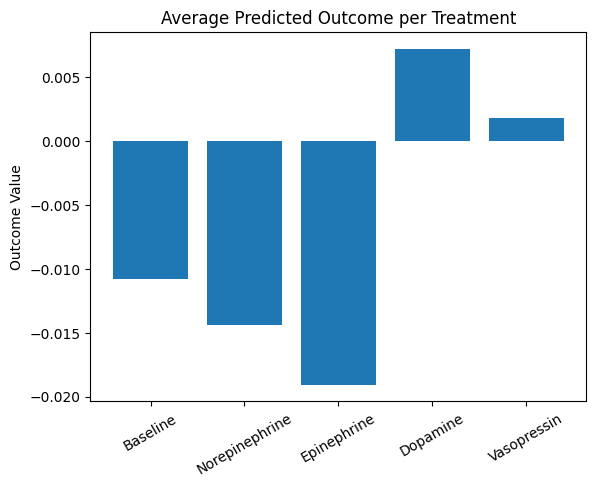

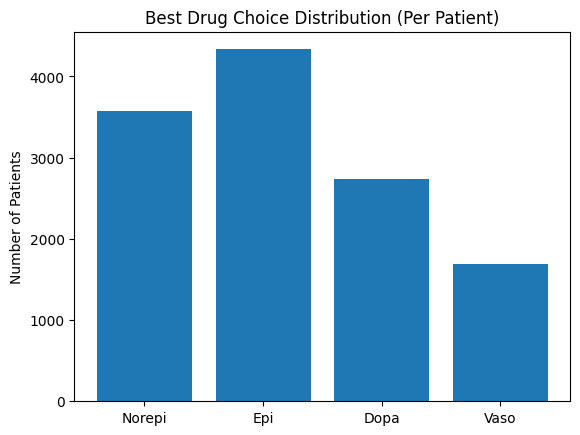

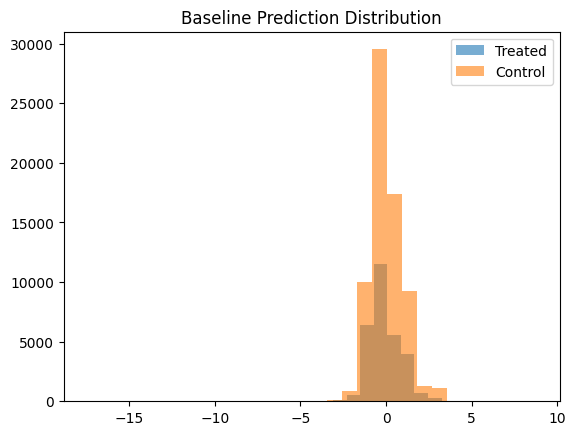

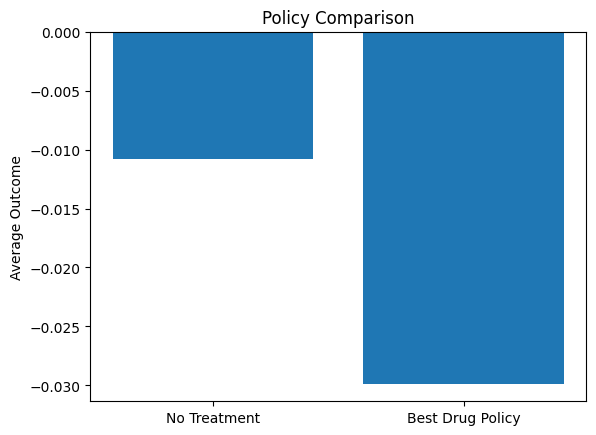

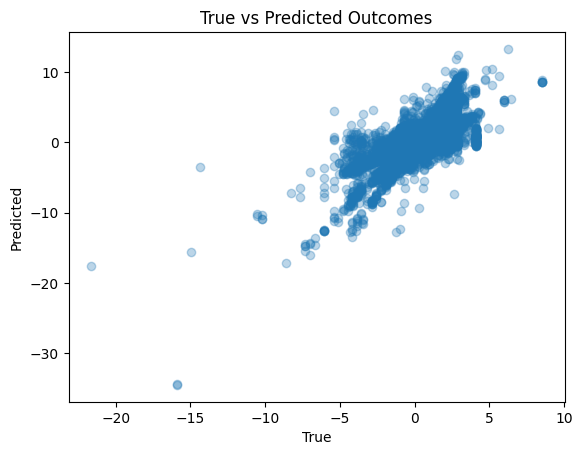

In [29]:
import matplotlib.pyplot as plt
import numpy as np

print("\n  VISUAL ANALYSIS  ")

# convert to numpy
y0_np = y0.detach().cpu().numpy()
y_treat_np = y_treatments.detach().cpu().numpy()


#  AVERAGE OUTCOME PER DRUG


# mean over samples and output dims
baseline_mean = y0_np.mean()
drug_means = y_treat_np.mean(axis=(0, 2))  # shape (4,)

labels = ["Baseline", "Norepinephrine", "Epinephrine", "Dopamine", "Vasopressin"]
values = [baseline_mean] + drug_means.tolist()

plt.figure()
plt.bar(labels, values)
plt.title("Average Predicted Outcome per Treatment")
plt.ylabel("Outcome Value")
plt.xticks(rotation=30)
plt.show()



#  BEST DRUG DISTRIBUTION


# best drug per sample
best_per_sample = y_treat_np.mean(axis=2).argmin(axis=1)

counts = np.bincount(best_per_sample, minlength=4)

plt.figure()
plt.bar(["Norepi", "Epi", "Dopa", "Vaso"], counts)
plt.title("Best Drug Choice Distribution (Per Patient)")
plt.ylabel("Number of Patients")
plt.show()



#  TREATED vs CONTROL BASELINE


treated_mask_np = treated_mask.cpu().numpy()
control_mask_np = control_mask.cpu().numpy()

plt.figure()
plt.hist(y0_np[treated_mask_np].flatten(), bins=30, alpha=0.6, label="Treated")
plt.hist(y0_np[control_mask_np].flatten(), bins=30, alpha=0.6, label="Control")
plt.title("Baseline Prediction Distribution")
plt.legend()
plt.show()



#  POLICY COMPARISON


policy_values = [policy_control.item(), policy_treated.item()]

plt.figure()
plt.bar(["No Treatment", "Best Drug Policy"], policy_values)
plt.title("Policy Comparison")
plt.ylabel("Average Outcome")
plt.show()



#  FACTUAL vs PREDICTED


factual_np = factual_pred.detach().cpu().numpy()
true_np = Y_test_tensor.detach().cpu().numpy()

plt.figure()
plt.scatter(true_np.flatten(), factual_np.flatten(), alpha=0.3)
plt.title("True vs Predicted Outcomes")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()